# Relatório Final - Data Science
## Bacharelado em Ciência da Computação / PUCPR (2026-1)

**Prof. Rayson Laroca**

Alander Menezes Arantes de Ávila - menezes.alander@pucpr.edu.br

Giancarlo Nunes Perli - giancarlo.perli@sanrocco.com.br

Gustavo Faria Cardoso - faria.cardoso@pucpr.edu.br

Paulo Henrique Perin - paulo.perin@pucpr.edu.br

Pedro Lucas Ghezzi Bittencourt - pedro.bittencourt@pucpr.edu.br

# Importações

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew as _skew, kurtosis as _kurt
from matplotlib.patches import Ellipse as MplEllipse, Patch
from matplotlib.lines import Line2D

#### O dataset foi adquirido através do Kaggle, é mantido pelo Laboratório de Propulsão a Jato do Instituto de Tecnologia da California, uma organização sob a NASA, e contém os seguintes atributos:

**Identificadores** — `id`, `spkid`, `full_name`, `pdes`, `name`, `prefix`, `orbit_id`: identificam entradas no catálogo, sem valor preditivo.

**Classificação**
- `neo` — *Near-Earth Object*: indica se o asteroide orbita na região próxima à Terra (Y/N).
- `pha` — *Potentially Hazardous Asteroid*: indica se o asteroide é classificado como potencialmente perigoso (Y/N). ⭐ **Variável-alvo do projeto.**

**Características físicas**
- `H` — Magnitude absoluta: medida de brilho intrínseco do asteroide. Quanto menor o valor, mais brilhante e geralmente maior o objeto.
- `diameter` — Diâmetro físico em km.
- `albedo` — Fração da luz solar refletida pela superfície (0 = completamente escuro, 1 = completamente reflexivo).

**Parâmetros orbitais**
- `e` — Excentricidade: descreve o formato da órbita. 0 = circular, próximo de 1 = muito alongada.
- `a` — Semi-eixo maior (AU): distância média do asteroide ao Sol.
- `q` — Periélio (AU): ponto mais próximo do Sol na órbita.
- `ad` — Afélio (AU): ponto mais distante do Sol na órbita.
- `i` — Inclinação (°): ângulo entre o plano da órbita do asteroide e o plano da eclíptica (plano da órbita da Terra).
- `w` — Argumento do periélio (°): orientação do ponto mais próximo ao Sol dentro do plano orbital.
- `n` — Movimento médio (°/dia): velocidade angular média ao longo da órbita.
- `per_y` — Período orbital em anos: tempo para completar uma volta ao redor do Sol.
- `moid` — Distância mínima de interseção orbital (AU): menor distância geométrica possível entre a órbita do asteroide e a da Terra.
- `moid_ld` — Mesmo que `moid`, expresso em distâncias lunares.

**Qualidade do ajuste orbital**
- `sigma_e` — Incerteza formal na excentricidade estimada.
- `rms` — Resíduo do ajuste orbital (arcsec): indica a qualidade do ajuste da órbita calculada às observações reais.

**Outros** — `class`: classe orbital dinâmica (MBA, APO, ATE, AMO, IEO…)

## **Objetivos do Projeto**

**Objetivo principal:** Construir um modelo de Machine Learning capaz de classificar, a partir de características físicas e/ou orbitais, se um asteroide é potencialmente perigoso (`pha = Y`), de forma que seja capaz de generalizar para asteroides não classificados.

**Objetivos secundários:**
- Identificar quais características físicas e orbitais melhor diferenciam PHAs dos demais asteroides.
- Avaliar a viabilidade das variáveis físicas (`diameter`, `albedo`, `H`) como features, considerando a alta taxa de valores ausentes.
- Investigar o desbalanceamento de classes e suas implicações para a modelagem.
- Comparar modelos com e sem `moid_ld`, avaliando se os parâmetros orbitais restantes são suficientes para a classificação.

## **Hipóteses**

- **H1:** Asteroides próximos a Terra tendem a ser mais perigosos.
- **H2:** Asteroides com maiores dimensões físicas são mais perigosos.
- **H3:** A geometria da órbita determina se um asteroide cruza a região da Terra.

# Carregamento dos Dados

In [24]:
ds = pd.read_csv(
    "https://github.com/aland3r/asteroides/releases/download/dataset/asteroids-dataset.csv",
    low_memory=False
)
print(f"Shape original: {ds.shape}")

Shape original: (958524, 45)


In [25]:
ds['neo'].value_counts()

neo
N    935625
Y     22895
Name: count, dtype: int64

# Limpeza e Tratamento

O dataset completo possui 958.524 registros e 45 colunas. O primeiro passo da limpeza foi remover as colunas identificadoras (`id`, `spkid`, `full_name`, `pdes`, `name`, `prefix` e `orbit_id`), que não carregam informação analítica. Em seguida, removemos os registros sem rótulo definido para asteroides potencialmente perigosos (`pha = NaN`), já que a variável alvo é indispensável para as análises supervisionadas.

Em seguida, removemos as colunas `diameter`, `albedo`, `diameter_sigma` e `diameter_bc`, todas com mais de 85% de valores ausentes. Antes de removê-las, verificamos se os valores presentes estavam concentrados nos PHAs, o que indicaria relevância preditiva. Não era o caso: a grande maioria dos valores pertencia à classe negativa (135.988 não-PHAs contra 221 PHAs para `diameter`), confirmando que a remoção não compromete a identificação de asteroides perigosos.

Por fim, filtramos o dataset para conter apenas NEOs (`neo = Y`). Como todo PHA é necessariamente um objeto próximo à Terra, os asteroides com `neo = N` nunca poderiam ser classificados como perigosos — sua inclusão apenas adicionaria ruído ao problema. Esse filtro reduz o dataset de 938.603 para 22.895 instâncias

In [26]:
ds.isnull().sum()

id                     0
spkid                  0
full_name              0
pdes                   0
name              936460
prefix            958506
neo                    4
pha                19921
H                   6263
diameter          822315
albedo            823421
diameter_sigma    822443
orbit_id               0
epoch                  0
epoch_mjd              0
epoch_cal              0
equinox                0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     1
ad                     4
n                      0
tp                     0
tp_cal                 0
per                    4
per_y                  1
moid               19921
moid_ld              127
sigma_e            19922
sigma_a            19922
sigma_q            19922
sigma_i            19922
sigma_om           19922
sigma_w            19922
sigma_ma           19922
sigma_ad           19926


In [27]:
df_clean = ds.dropna(subset=['pha'])

id_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id']
high_missing = ['diameter', 'albedo', 'diameter_sigma', 'diameter_bc']
df_clean = df_clean.drop(columns=id_cols + high_missing, errors='ignore')
df_clean = df_clean[df_clean['neo'] == 'Y']
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_clean.shape)
print(df_clean['pha'].value_counts())

(22894, 35)
pha
N    20828
Y     2066
Name: count, dtype: int64


### **Amostragem Balanceada**

O desbalanceamento de classes em `pha` dificulta a comparação visual entre os dois grupos. Para contornar isso, construímos `df_equal`: um subconjunto com igual número de PHAs e não-PHAs (2.066 de cada), totalizando 4.132 instâncias, com semente aleatória fixa para reprodutibilidade. Estatísticas populacionais e treinamento dos modelos utilizam `df_clean`; `df_equal` é reservado para visualizações exploratórias onde uma comparação visual justa entre as classes é necessária.

In [28]:
# df_clean contém apenas pha em {'Y','N'}

# separar classes
df_y = df_clean[df_clean['pha'] == 'Y'].copy()
df_n = df_clean[df_clean['pha'] == 'N'].copy()

# amostra balanceada: mesma quantidade de N que de Y
df_n_bal = df_n.sample(n=len(df_y), random_state=42)

# conjunto balanceado final
df_equal = pd.concat([df_y, df_n_bal], ignore_index=True)
df_equal = df_equal.sample(frac=1, random_state=42).reset_index(drop=True)

# verificação
print("df_equal shape:", df_equal.shape)
print(df_equal['pha'].value_counts())
print(df_equal['pha'].value_counts(normalize=True))

df_equal shape: (4132, 35)
pha
Y    2066
N    2066
Name: count, dtype: int64
pha
Y    0.5
N    0.5
Name: proportion, dtype: float64


---

# Descrição Estatística



Após a limpeza:

- 43.386 instâncias (2.066 PHAs e 41.320 não-PHAs);
- 38 atributos;
- **Problema:** classificação binária — `pha = Y` ou `pha = N`
- **Desbalanceamento:** mesmo após a redução, apenas ~4,8% dos asteroides são PHAs — qualquer modelo que preveja sempre "não perigoso" acertaria ~95% das vezes, tornando a acurácia uma métrica inadequada

In [29]:
# Cores oficiais do projeto
PHA_COLORS = {
    'Y': '#6B3FA0',  # roxo metálico - Potentially Hazardous
    'N': '#2EAF8A'   # verde-azulado brilhante - Non-Hazardous
}

---

# Análise de Dados univariados

#### **1. Qual é a proporção de asteroides potencialmente perigosos?**

In [30]:
ds['pha'].value_counts()
df_clean['pha'].value_counts()

pha
N    20828
Y     2066
Name: count, dtype: int64

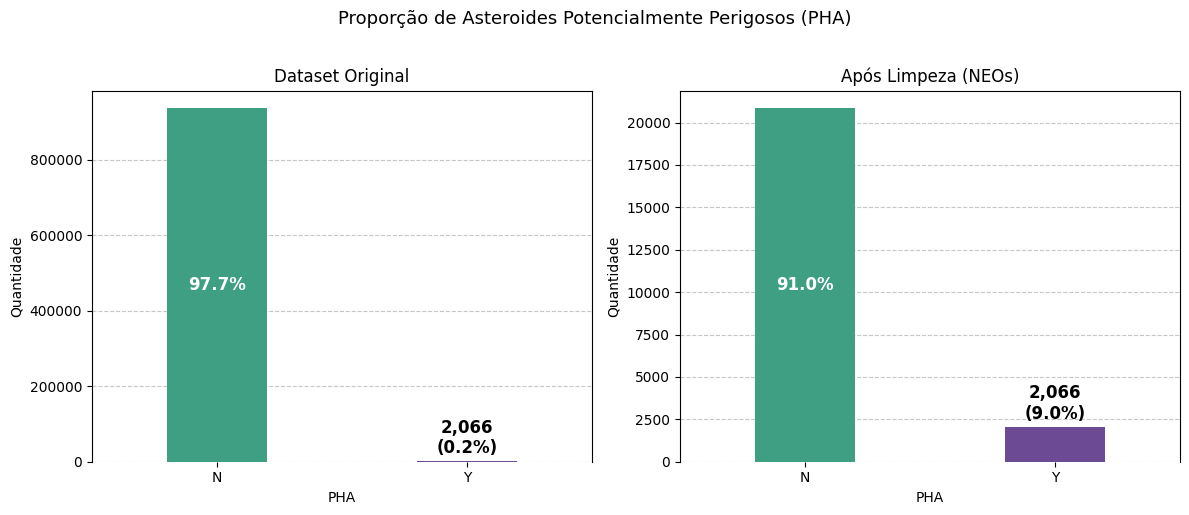

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Proporção de Asteroides Potencialmente Perigosos (PHA)', 
             fontsize=13, y=1.02)

datasets = [('Dataset Original', ds), ('Após Limpeza (NEOs)', df_clean)]

for ax, (titulo, data) in zip(axes, datasets):
    contagem = data['pha'].value_counts()
    
    sns.barplot(x=contagem.index, y=contagem.values, ax=ax, width=0.4,
                hue=contagem.index, palette=PHA_COLORS, legend=False)
    
    ax.set_title(titulo)
    ax.set_xlabel('PHA')
    ax.set_ylabel('Quantidade')
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines['bottom'].set_visible(False)  # remove linha inferior em ambos

    for i, (label, v) in enumerate(zip(contagem.index, contagem.values)):
        pct = v / len(data) * 100
        if label == 'N':
            ax.text(i, v / 2, f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white')
        else:
            ax.text(i, v + len(data) * 0.01, f'{v:,}\n({pct:.1f}%)',
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Há um desbalanceamento extremo no dataset original: apenas 0,2% dos asteroides (2.066) são potencialmente perigosos(`pha=Y`), contra 97,7% (936.537) não perigosos (`pha=N`). Após a limpeza e o filtro para objetos próximos à Terra (`neo=Y`), essa proporção vai para aproximadamente 9% de `pha=Y` e 91% de `pha=N`, ainda discrepante, porém mais tratável. Em ambos os casos, será necessário ajustar a districuição de classes na etapa de pré-processamento. Métricas como acurácia isolada também não serão suficientes para avaliar o modelo, sendo necessário considerar F1-score, precisão e recall.

#### **2. Qual a proporção de asteroides próximos à Terra?**

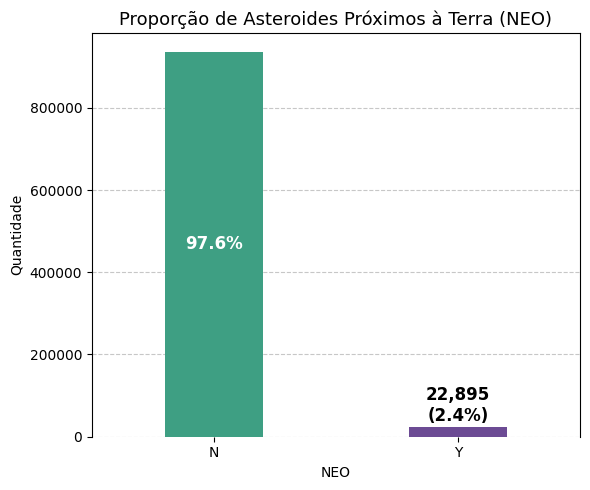

In [32]:
fig, ax = plt.subplots(figsize=(6, 5))

contagem = ds['neo'].value_counts()

sns.barplot(x=contagem.index, y=contagem.values, ax=ax, width=0.4,
            hue=contagem.index, palette=PHA_COLORS, legend=False)

ax.set_title('Proporção de Asteroides Próximos à Terra (NEO)', fontsize=13)
ax.set_xlabel('NEO')
ax.set_ylabel('Quantidade')
ax.spines['bottom'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

for i, (label, v) in enumerate(zip(contagem.index, contagem.values)):
    pct = v / len(ds) * 100
    if label == 'N':
        ax.text(i, v / 2, f'{pct:.1f}%',
                ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')
    else:
        ax.text(i, v + 5000, f'{v:,}\n({pct:.1f}%)',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

Apenas 2,4% dos asteroides (22.895) são objetos próximos à Terra (`neo=Y`), contra 97,6% (935.625) que orbitam longe (`neo=N`), refletindo a dominância do cinturão principal no sistema solar. Embora minoritários, os NEOs são centrais para o projeto: todo asteroide potencialmente perigoso (`pha=Y`) é necessariamente um NEO, mas nem todo NEO é um PHA. Essa relação motivou a decisão de filtrar o dataset para esse subconjunto na etapa de limpeza, reduzindo de 958.524 para 22.895 instâncias.

#### **3. Qual é a distribuição das classes orbitais no dataset e como isso se relaciona com a classificação de risco?**

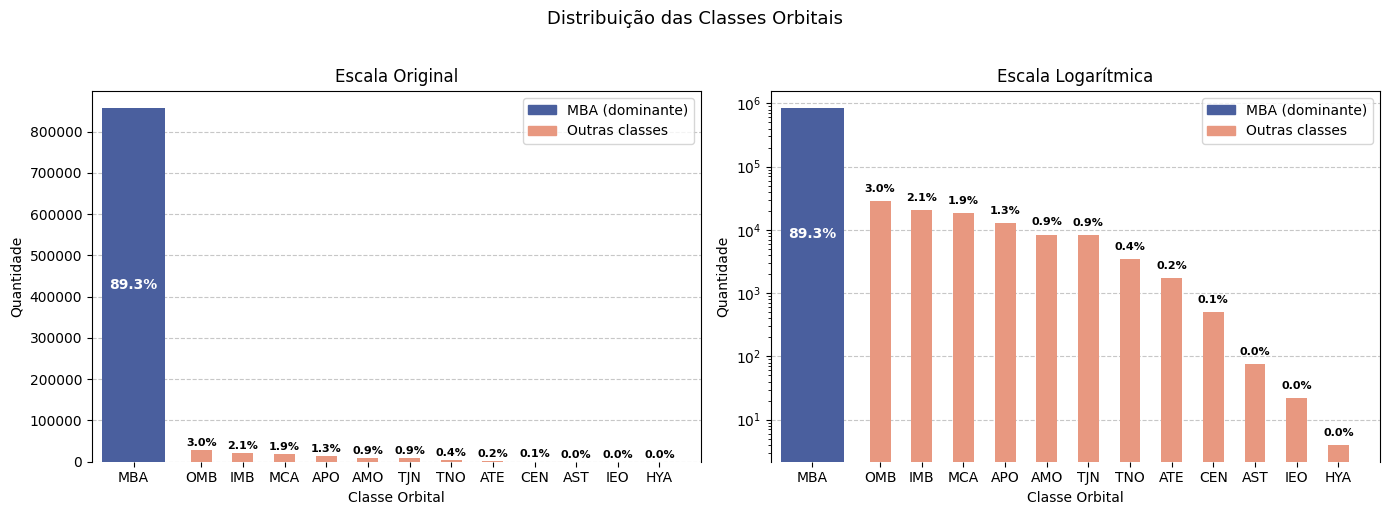

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição das Classes Orbitais', fontsize=13, y=1.02)

contagem = ds['class'].value_counts()
labels = list(contagem.index)
values = list(contagem.values)

COR_MBA    = '#4A5F9E'  # azul escuro - classe dominante
COR_OUTRAS = '#E89880'  # terracota suave - outras classes

espacamento = 0.8
offset_mba  = 0.5

posicoes = []
for i, label in enumerate(labels):
    if i == 0:
        posicoes.append(0)
    else:
        posicoes.append(offset_mba + i * espacamento)

for ax, log in zip(axes, [False, True]):
    for pos, label, v in zip(posicoes, labels, values):
        cor  = COR_MBA if label == 'MBA' else COR_OUTRAS
        larg = 1.2     if label == 'MBA' else 0.4
        ax.bar(pos, v, width=larg, color=cor)

    ax.set_xticks(posicoes)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.8, posicoes[-1] + 0.8)
    ax.set_xlabel('Classe Orbital')
    ax.set_ylabel('Quantidade')
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    if log:
        ax.set_yscale('log')
        ax.set_title('Escala Logarítmica')
    else:
        ax.set_title('Escala Original')

    for pos, label, v in zip(posicoes, labels, values):
        pct = v / len(ds) * 100
        if label == 'MBA':
            y_pos = v / 2 if not log else v * 0.01
            ax.text(pos, y_pos, f'{pct:.1f}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        else:
            y_pos = v * 1.3 if log else v + 5000
            ax.text(pos, y_pos, f'{pct:.1f}%',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color='black')

from matplotlib.patches import Patch
for ax in axes:
    ax.legend(handles=[Patch(color=COR_MBA,    label='MBA (dominante)'),
                       Patch(color=COR_OUTRAS, label='Outras classes')],
              loc='upper right')

plt.tight_layout()
plt.show()

O dataset original é amplamente dominado por asteroides do cinturão principal (MBA), que representam 89,3% das instâncias. A escala logarítmica revela que as demais classes, apesar de numericamente minoritárias, são igualmente importantes para o objetivo do projeto. Em particular, as classes APO, ATE, AMO e IEO, coletivamente conhecidas como NEOs, são as únicas cujas órbitas se aproximam ou cruzam a órbita da Terra, sendo portanto os únicos candidatos reais à classificação `pha=Y`. Essa concentração de PHAs nas classes NEO reforça a decisão de filtrar o dataset para esse subconjunto na etapa de limpeza, reduzindo de 958.524 para 22.895 instâncias e aumentando a proporção de PHAs de 0,2% para 9%.

#### **4. Como se distribui a magnitude absoluta (`H`) no dataset?**

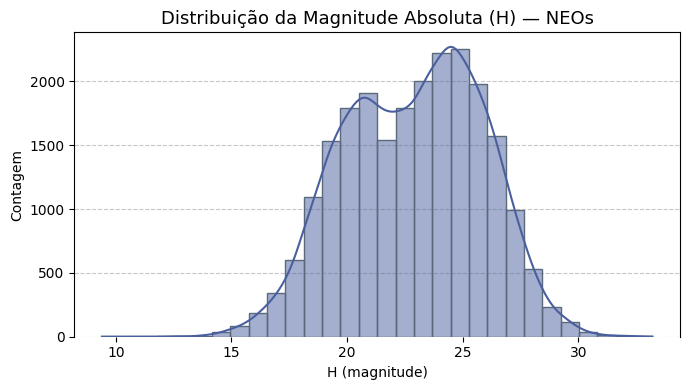

count    22883.000000
mean        22.869722
std          2.984633
min          9.400000
25%         20.600000
50%         23.100000
75%         25.185000
max         33.200000
Name: H, dtype: float64


In [34]:
data_H = df_clean['H'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(data_H, bins=30, kde=True, ax=ax, color='#4A5F9E', edgecolor='#5A6A7A')
ax.set_title('Distribuição da Magnitude Absoluta (H) — NEOs', fontsize=13)
ax.set_xlabel('H (magnitude)')
ax.set_ylabel('Contagem')
ax.spines['bottom'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
print(data_H.describe())

A magnitude absoluta (`H`) está disponível para 99,3% dos asteroides, tornando-a a variável física mais confiável do dataset para estimar o tamanho do asteroide. Embora `diameter` fosse uma medida mais direta, foi removido por ter mais de 85% de valores ausentes — `H` assume esse papel, já que objetos maiores são mais brilhantes e, portanto, apresentam menor valor de `H`. Nos NEOs, sua distribuição é aproximadamente normal com pico entre H=20 e H=25, correspondendo a objetos de tamanho médio.

#### **6. Quais são os valores extremos de distância entre os objetos próximos à Terra?**

Q1: 6.09 | Q3: 55.51 | IQR: 49.42
Limite superior: 129.64
Outliers: 710 (3.1%)


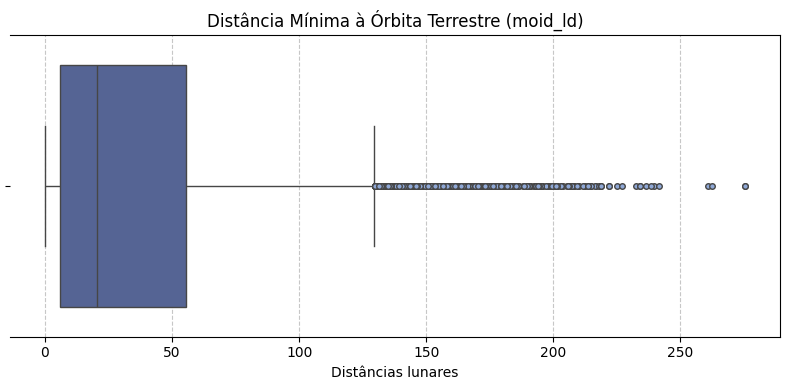

In [35]:
Q1 = df_clean['moid_ld'].quantile(0.25)
Q3 = df_clean['moid_ld'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['moid_ld'] < limite_inferior) | 
                    (df_clean['moid_ld'] > limite_superior)]

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_clean['moid_ld'], ax=ax,
            color='#4A5F9E', flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
ax.set_title('Distância Mínima à Órbita Terrestre (moid_ld)')
ax.set_xlabel('Distâncias lunares')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

A distância mínima à Terra (`moid_ld`) apresenta uma distribuição assimétrica à direita, com mediana próxima a 30 distâncias lunares e 3,1% de outliers acima do limite superior de 129,64 distâncias lunares. A maioria dos NEOs passa relativamente perto da Terra, mas uma minoria tem órbitas que se afastam consideravelmente. Esses valores extremos representam NEOs que, apesar de classificados como objetos próximos à Terra, mantêm distância orbital segura, reforçando que proximidade não implica risco real.

#### **7. Como se distribui a excentricidade orbital (`e`)?**

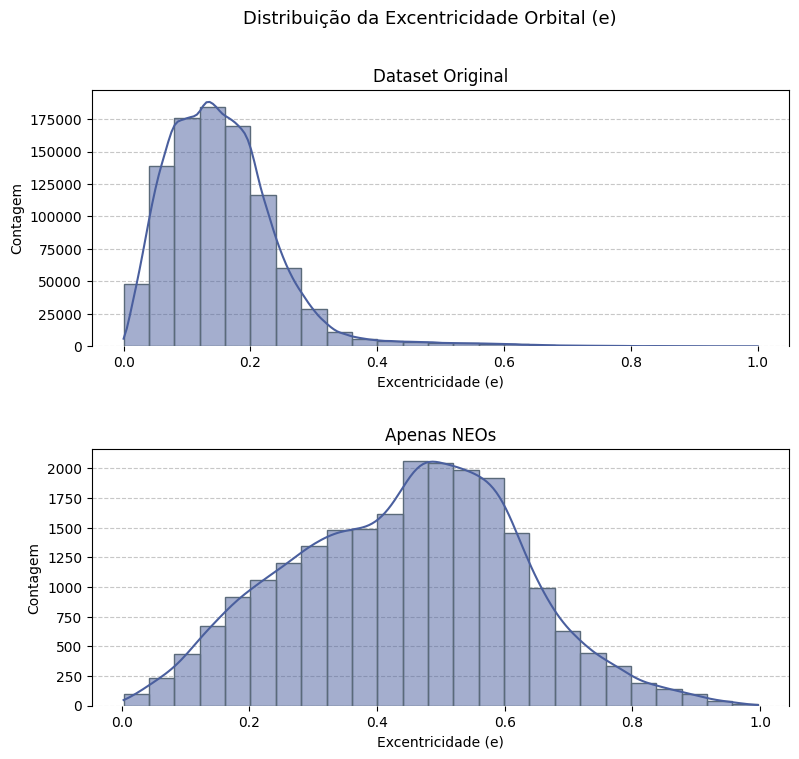

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8))
fig.suptitle('Distribuição da Excentricidade Orbital (e)', fontsize=13)
plt.subplots_adjust(hspace=0.4)

datasets = [('Dataset Original', ds), ('Apenas NEOs', df_clean)]

for ax, (titulo, data) in zip(axes, datasets):
    d = data.loc[(data['e'] >= 0) & (data['e'] < 1), 'e']
    sns.histplot(d, bins=25, kde=True, ax=ax, color='#4A5F9E', edgecolor='#5A6A7A')
    ax.set_title(titulo)
    ax.set_xlabel('Excentricidade (e)')
    ax.set_ylabel('Contagem')
    ax.spines['bottom'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.show()

No dataset original, dominado por asteroides do cinturão principal, a excentricidade se concentra entre 0,1 e 0,2 — órbitas quase circulares. Nos NEOs, a distribuição se desloca significativamente para a direita, com pico entre 0,4 e 0,6, confirmando que objetos próximos à Terra possuem órbitas intrinsecamente mais elongadas. Essa diferença não é coincidência: para um asteroide cruzar a região interna do sistema solar e se aproximar da Terra, sua órbita precisa ser elíptica. A hipótese de que PHAs concentram valores ainda mais altos de `e` será investigada nas análises multivariadas.

#### **9. A magnitude absoluta (`H`) dos objetos próximos à Terra (`neo=Y`) apresenta valores extremos?**

Q1: 20.60 | Q3: 25.18 | IQR: 4.58
Limite inferior: 13.72
Limite superior: 32.06
Outliers: 13 (0.1%)


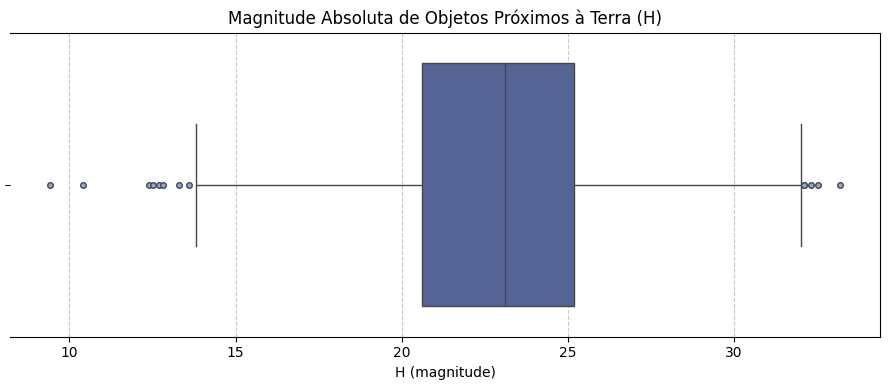

In [37]:
Q1 = df_clean['H'].quantile(0.25)
Q3 = df_clean['H'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['H'] < limite_inferior) | (df_clean['H'] > limite_superior)]

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(x=df_clean['H'], ax=ax, color='#4A5F9E',
            flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
ax.set_title('Magnitude Absoluta de Objetos Próximos à Terra (H)')
ax.set_xlabel('H (magnitude)')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

A magnitude absoluta (`H`) dos objetos próximos à Terra apresenta poucos valores extremos, apenas 13 outliers (0,1%), distribuídos em ambos os extremos. O intervalo interquartil concentra-se entre 20,60 e 25,18, representando asteroides de tamanho médio. Os outliers à esquerda (H baixo) correspondem a objetos grandes e brilhantes, raros entre os NEOs. Os à direita (H alto) são asteroides muito pequenos e pouco brilhantes. A baixa presença de outliers indica que a variável não exigirá tratamento especial nessa etapa.

#### **10. A excentricidade orbital (`e`) dos objetos próximos à Terra (`neo=Y`) apresenta valores extremos?**

Q1: 0.31 | Q3: 0.57 | IQR: 0.26
Limite inferior: -0.07
Limite superior: 0.95
Outliers: 17 (0.1%)


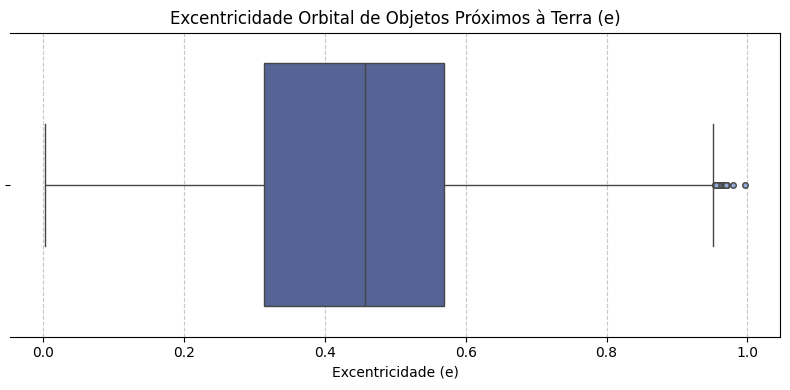

In [38]:
Q1 = df_clean['e'].quantile(0.25)
Q3 = df_clean['e'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['e'] < limite_inferior) | 
                    (df_clean['e'] > limite_superior)]

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_clean['e'], ax=ax, color='#4A5F9E',
            flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
ax.set_title('Excentricidade Orbital de Objetos Próximos à Terra (e)')
ax.set_xlabel('Excentricidade (e)')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

O método de Tukey identificou apenas 17 outliers (0,1%) para a excentricidade orbital (`e`) dos objetos próximos à Terra (`neo=Y`), todos acima do limite superior de 0,95, asteroides com órbitas extremamente alongadas, próximas de parabólicas. O limite inferior resultou negativo (-0,07), fisicamente impossível, confirmando que não há outliers abaixo. A distribuição é ampla, com Q1=0,31 e Q3=0,57, refletindo a natureza dos objetos próximos à Terra, cujas órbitas precisam ser elípticas para cruzar a região interna do sistema solar. Essa amplitude é esperada e a excentricidade (`e`) é uma das variáveis com maior potencial discriminante entre PHAs e não-PHAs.

#### **11. A distância do periélio (`q`) dos objetos próximos à Terra apresenta valores extremos?**

Q1: 0.78 | Q3: 1.07 | IQR: 0.28
Limite inferior: 0.36
Limite superior: 1.50
Outliers: 548 (2.4%)


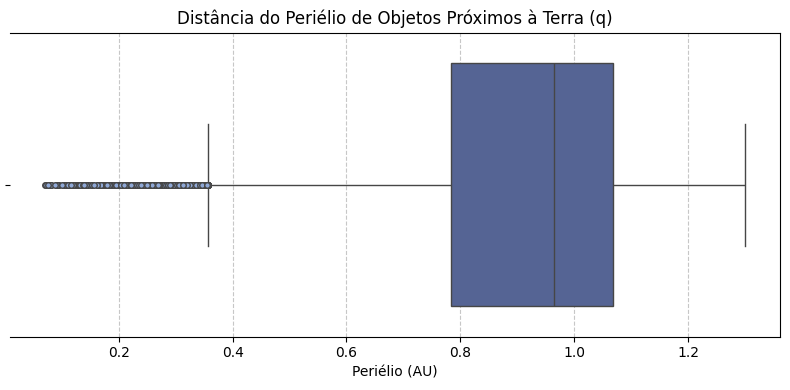

In [39]:
Q1 = df_clean['q'].quantile(0.25)
Q3 = df_clean['q'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['q'] < limite_inferior) | 
                    (df_clean['q'] > limite_superior)]

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_clean['q'], ax=ax, color='#4A5F9E',
            flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
ax.set_title('Distância do Periélio de Objetos Próximos à Terra (q)')
ax.set_xlabel('Periélio (AU)')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

A distância do periélio (`q`) representa o ponto mais próximo do Sol na órbita de um asteroide, medido em unidades astronômicas (AU), onde 1 AU equivale à distância média entre a Terra e o Sol. Quanto menor o valor de `q`, mais internamente o asteroide penetra no sistema solar em sua trajetória.

Nos objetos próximos à Terra (`neo=Y`), o método de Tukey identificou 548 outliers (2,4%), todos abaixo do limite inferior de 0,36 AU, asteroides cujo ponto mais próximo do Sol está bem dentro da órbita de Vênus. O intervalo interquartil concentra-se entre 0,78 e 1,07 AU, próximo à órbita da Terra (1 AU), o que faz sentido para objetos que por definição cruzam ou se aproximam dessa região. Os outliers representam asteroides com órbitas muito internas, como os do tipo Atens (`ATE`) e Atiras (`IEO`), que passam a maior parte do tempo dentro da órbita terrestre.

#### **12. O semi-eixo maior (`a`) apresenta outliers significativos entre os objetos próximos à Terra (NEO = Y)?**

Q1: 1.31 | Q3: 2.19 | IQR: 0.88
Limite inferior: -0.02
Limite superior: 3.52
Outliers: 48 (0.2%)


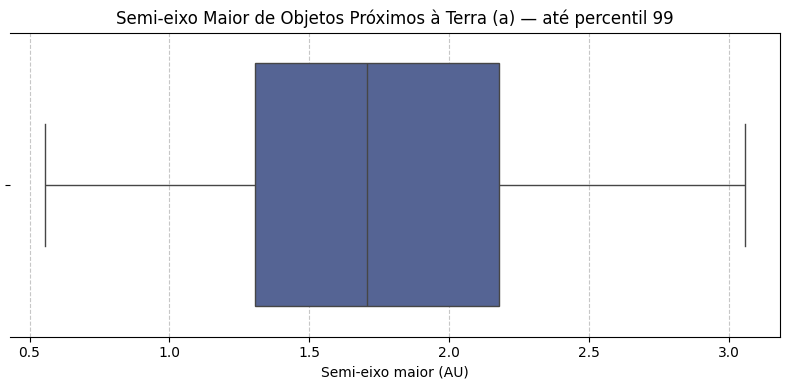

In [41]:
Q1 = df_clean['a'].quantile(0.25)
Q3 = df_clean['a'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean['a'] < limite_inferior) | 
                    (df_clean['a'] > limite_superior)]

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

p99 = df_clean['a'].quantile(0.99)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df_clean['a'][df_clean['a'] <= p99], ax=ax, color='#4A5F9E',
            flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
ax.set_title('Semi-eixo Maior de Objetos Próximos à Terra (a) — até percentil 99')
ax.set_xlabel('Semi-eixo maior (AU)')
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

O semi-eixo maior (`a`) define o tamanho médio da órbita de um asteroide, ou seja, a distância média ao Sol em unidades astronômicas (AU). Nos objetos próximos à Terra (`neo=Y`), o intervalo interquartil concentra-se entre 1,31 e 2,19 AU, com mediana próxima a 1,75 AU. O limite inferior resultou negativo (-0,02), fisicamente impossível, confirmando que não há outliers abaixo. Os 48 outliers (0,2%) acima de 3,52 AU representam asteroides com órbitas mais distantes, na fronteira do cinturão principal. A visualização foi truncada no percentil 99 para melhor legibilidade, dado que valores extremos distorceriam a escala.

#### **13. Como se distribui a inclinação orbital (`i`) os obejtos próximoa à Terra(`NEO = Y`)?**

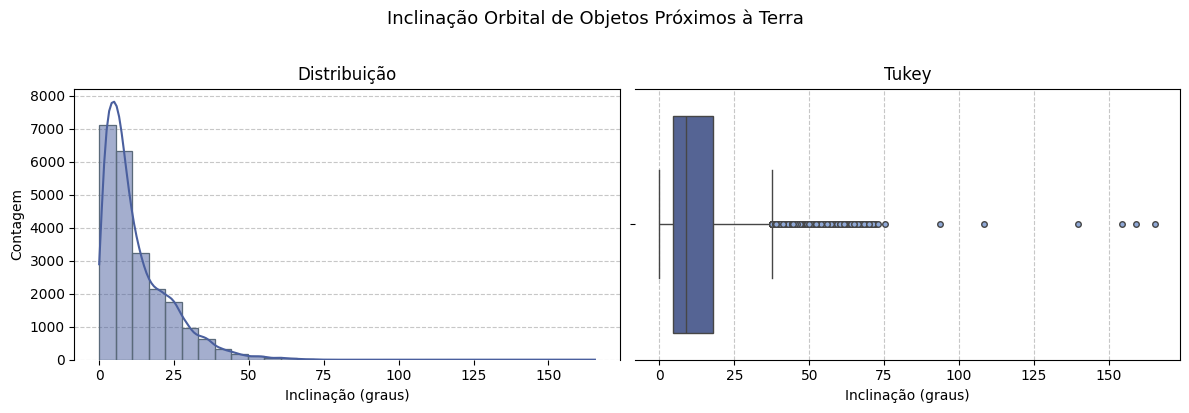

Q1: 4.58 | Q3: 17.74 | IQR: 13.16
Limite superior: 37.48
Outliers: 815 (3.6%)
count    22894.000000
mean        12.518875
std         11.124794
min          0.013518
25%          4.580578
50%          8.841965
75%         17.740475
max        165.541000
Name: i, dtype: float64


In [ ]:
data_i = df_clean['i']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Inclinação Orbital de Objetos Próximos à Terra', fontsize=13, y=1.02)

sns.histplot(data_i, bins=30, kde=True, ax=axes[0], color='#4A5F9E', edgecolor='#5A6A7A')
axes[0].set_title('Distribuição')
axes[0].set_xlabel('Inclinação (graus)')
axes[0].set_ylabel('Contagem')
axes[0].spines['bottom'].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

Q1 = data_i.quantile(0.25)
Q3 = data_i.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers = data_i[data_i > limite_superior]

sns.boxplot(x=data_i, ax=axes[1], color='#4A5F9E',
            flierprops=dict(markerfacecolor='#8FA8D6', markersize=4))
axes[1].set_title('Tukey')
axes[1].set_xlabel('Inclinação (graus)')
axes[1].spines['left'].set_visible(False)
axes[1].xaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f'Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}')
print(f'Limite superior: {limite_superior:.2f}')
print(f'Outliers: {len(outliers)} ({len(outliers)/len(data_i)*100:.1f}%)')
print(data_i.describe())

A maioria dos NEOs orbita em planos próximos ao da Terra (0° a 30°), o que facilita encontros gravitacionais. PHAs tendem a inclinações menores — órbitas mais coplanares com a Terra maximizam a probabilidade de interseção orbital.

A inclinação orbital (`i`) mede o ângulo entre o plano da órbita do asteroide e o plano da eclíptica (órbita da Terra). Nos NEOs, a distribuição é assimétrica à direita, com concentração entre 0° e 30° — a maioria orbita em planos próximos ao da Terra, o que facilita encontros gravitacionais. Uma cauda se estende até inclinações altas (>60°), representando asteroides em órbitas mais inclinadas que, apesar de cruzarem a região terrestre, têm menor probabilidade de colisão por conta do ângulo de interseção. PHAs tendem a apresentar inclinações menores, pois órbitas mais coplanares com a Terra maximizam o tempo de exposição mútua — hipótese que será investigada nas análises multivariadas.

---

#### **14. Qual a distribuição do `moid` (distância mínima orbital em AU) nos NEOs e qual fração está abaixo do limiar de risco?**

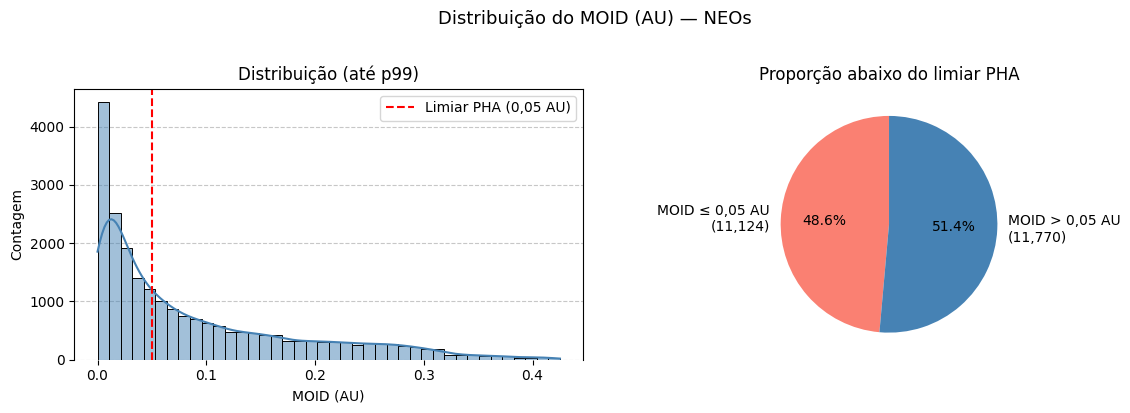

count    2.289400e+04
mean     9.334441e-02
std      1.021081e-01
min      4.544120e-07
25%      1.564305e-02
50%      5.287505e-02
75%      1.426343e-01
max      7.077220e-01
Name: moid, dtype: float64


In [ ]:
data_moid = ds_neo['moid'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuição do MOID (AU) — NEOs', fontsize=13, y=1.02)

# histograma com limite PHA
p99 = data_moid.quantile(0.99)
sns.histplot(data_moid[data_moid <= p99], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=1.5, label='Limiar PHA (0,05 AU)')
axes[0].set_title('Distribuição (até p99)')
axes[0].set_xlabel('MOID (AU)')
axes[0].set_ylabel('Contagem')
axes[0].legend()
axes[0].spines['bottom'].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

# pizza: abaixo vs acima do limiar
abaixo = (data_moid <= 0.05).sum()
acima  = (data_moid  > 0.05).sum()
axes[1].pie([abaixo, acima],
            labels=[f'MOID ≤ 0,05 AU\n({abaixo:,})', f'MOID > 0,05 AU\n({acima:,})'],
            autopct='%1.1f%%',
            colors=['salmon', 'steelblue'],
            startangle=90)
axes[1].set_title('Proporção abaixo do limiar PHA')

plt.tight_layout()
plt.show()
print(data_moid.describe())


O `moid` (Minimum Orbit Intersection Distance) em AU é um dos dois critérios formais para classificação como PHA — um asteroide é PHA se `moid ≤ 0,05 AU` **e** `H ≤ 22`. A distribuição nos NEOs é fortemente assimétrica à direita, com grande concentração de valores baixos: a pizza revela a proporção de NEOs que já atendem ao critério de proximidade, independentemente do tamanho. Esse gráfico complementa a análise do `moid_ld` (Q6) e é central para entender por que o desbalanceamento de classes muda drasticamente ao filtrarmos o dataset para NEOs — a proporção de PHAs sobe de 0,2% para ~9%, tornando o problema de classificação muito mais tratável.

---

#### **15. Como se distribui o período orbital (`per_y`) nos NEOs?**

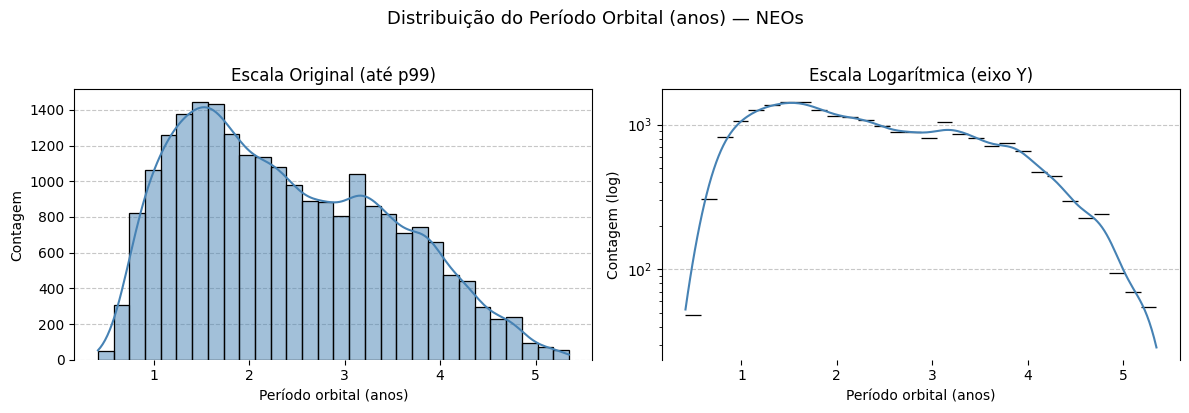

count    22666.000000
mean         2.390216
std          1.079229
min          0.413941
25%          1.493140
50%          2.226995
75%          3.213672
max          5.350129
Name: per_y, dtype: float64


In [ ]:
data_per = ds_neo['per_y'].dropna()
p99 = data_per.quantile(0.99)
data_per_clip = data_per[data_per <= p99]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribuição do Período Orbital (anos) — NEOs', fontsize=13, y=1.02)

sns.histplot(data_per_clip, bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Escala Original (até p99)')
axes[0].set_xlabel('Período orbital (anos)')
axes[0].set_ylabel('Contagem')
axes[0].spines['bottom'].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[0].set_axisbelow(True)

sns.histplot(data_per_clip, bins=30, kde=True, ax=axes[1], color='steelblue', log_scale=(False, True))
axes[1].set_title('Escala Logarítmica (eixo Y)')
axes[1].set_xlabel('Período orbital (anos)')
axes[1].set_ylabel('Contagem (log)')
axes[1].spines['bottom'].set_visible(False)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()
print(data_per_clip.describe())


O período orbital (`per_y`) é diretamente derivado do semi-eixo maior `a` pela terceira lei de Kepler (T² ∝ a³), e por isso reflete a mesma estrutura: NEOs têm períodos concentrados entre 1 e 4 anos, compatíveis com órbitas na região interna do sistema solar entre a Terra e Marte. A distribuição é assimétrica à direita, com poucos NEOs de períodos mais longos (órbitas que se estendem além de Marte). Asteroides com períodos próximos a 1 ano orbitam de forma quase sincronizada com a Terra, aumentando a frequência de encontros próximos — o que reforça a hipótese de que a geometria orbital é determinante para a periculosidade.

---

#### 20. Qual é a precisão dos dados orbitais? Como se distribui a incerteza na excentricidade (`sigma_e`)?

# **Análises Multivariadas**

### **1. Asteroides com órbitas mais alongadas tendem a ser mais perigosos?**

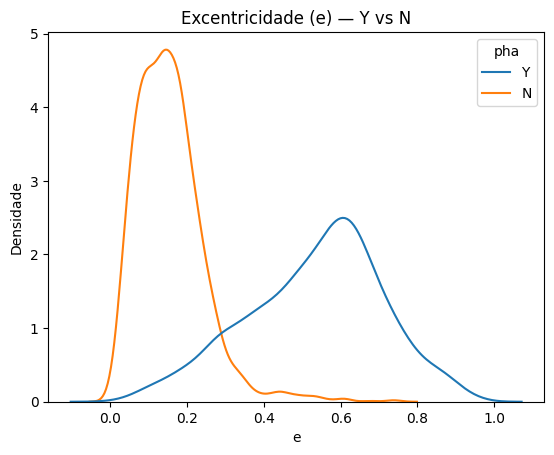

In [ ]:
sns.kdeplot(data=df_sample, x="e", hue="pha", common_norm=False)
plt.title("Excentricidade (e) — Y vs N")
plt.xlabel("e")
plt.ylabel("Densidade")
plt.show()

Suspeitamos que haveria uma diferença entre os formatos de órbita de asteroides potencialmente perigosos e não perigosos. O gráfico confirma essa suspeita. As curvas KDE mostram separação clara: PHAs oncentram-se em excentricidades mais altas enquanto não-PHAs  têm pico em valores muito mais baixos. As duas distribuições mal se sobrepõem — A excentricidade é um forte discriminador entre as classes.

Asteroides não perigosos (`PHA=N`) concentram-se em excentricidades baixas (~0,15), com órbitas quase circulares típicas do cinturão principal. Já os potencialmente perigosos (`PHA=Y`) apresentam pico em torno de 0,6 — órbitas muito mais alongadas, que em seu ponto mais próximo do Sol adentram a região interna do sistema solar e intersectam a órbita terrestre. Quanto mais elíptica a órbita, maior a chance do asteroide se aproximar perigosamente da Terra.

---

### **2. Asteroides que orbitam mais próximos ao Sol tendem a ser mais perigosos?**

**Hipótese:** PHAs devem concentrar-se com semi-eixo maior próximo a 1 AU.

**Variáveis:** `a` e `pha` | **Visualização:** KDE por classe

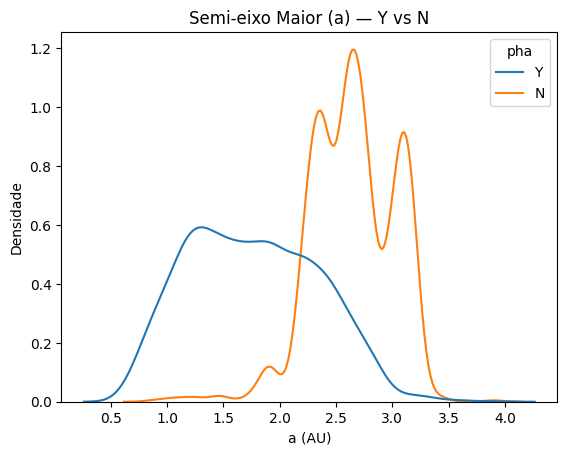

In [ ]:
data = df_sample[df_sample["a"] <= df_sample["a"].quantile(0.99)]
sns.kdeplot(data=data, x="a", hue="pha", common_norm=False)
plt.title("Semi-eixo Maior (a) — Y vs N")
plt.xlabel("a (AU)")
plt.ylabel("Densidade")
plt.show()

**Confirmado.** PHAs concentram-se na região próxima à Terra (~1 AU) enquanto não-PHAs têm pico em ~2,5–3 AU (cinturão principal). A separação é clara com alguma sobreposição ao redor de 2 AU.

---

### **6. Quais variáveis orbitais são redundantes entre si?**

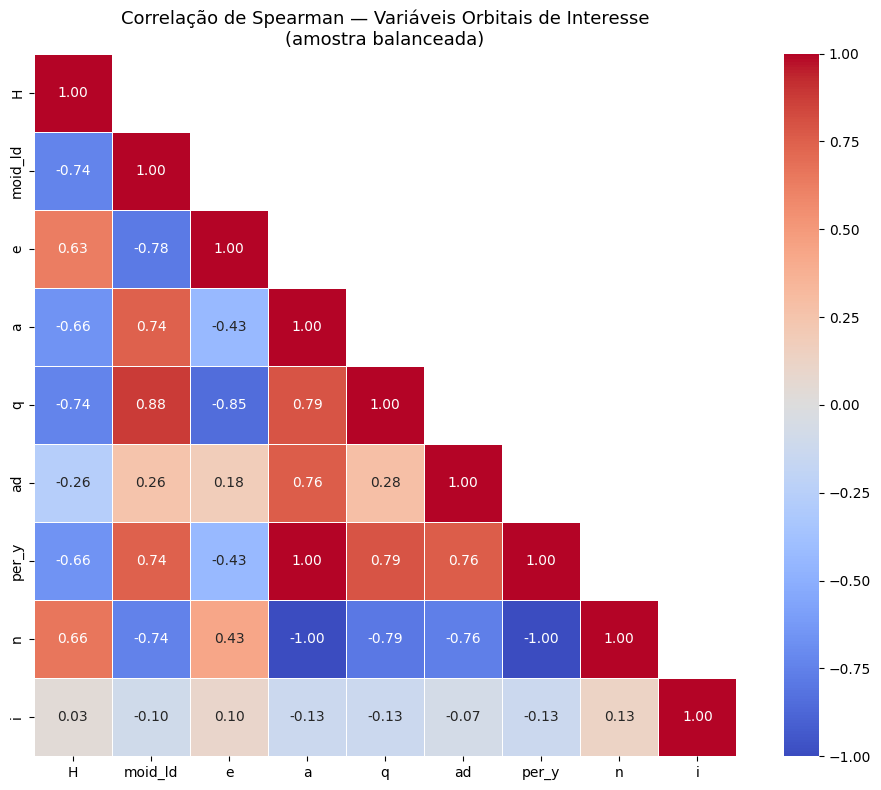

In [ ]:
interest_cols = ['H', 'moid_ld', 'e', 'a', 'q', 'ad', 'per_y', 'n', 'i']
spearman_corr = df_sample[interest_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Correlação de Spearman — Variáveis Orbitais de Interesse\n(amostra balanceada)', fontsize=13)
plt.tight_layout()
plt.show()

**Hipótese:** `a`, `ad`, `per_y` e `n` devem ser altamente correlacionados pela terceira lei de Kepler. `H` e `moid_ld` — os dois critérios formais de PHA — devem ser independentes entre si.

**Método:** Correlação de Spearman (mais robusta para distribuições assimétricas)

**Confirmado.** `a`, `ad` e `per_y` correlacionam-se próximos de +1,0 — são essencialmente a mesma informação pela terceira lei de Kepler. `n` correlaciona-se negativamente com `a`. `H` e `moid_ld` mostram correlação fraca — os dois critérios formais de PHA medem aspectos independentes. Na modelagem, a multicolinearidade entre `a`, `ad`, `per_y` e `n` precisará ser tratada com seleção de features.

---

# Gráficos Finais (Visualização Eficaz de Dados)

Três visualizações aprimoradas para um público sem conhecimento técnico em astronomia. Cada gráfico usa `df_sample` para comparação visual equilibrada entre as classes.

### **1. A Zona de Risco PHA: Tamanho e Proximidade Orbital**

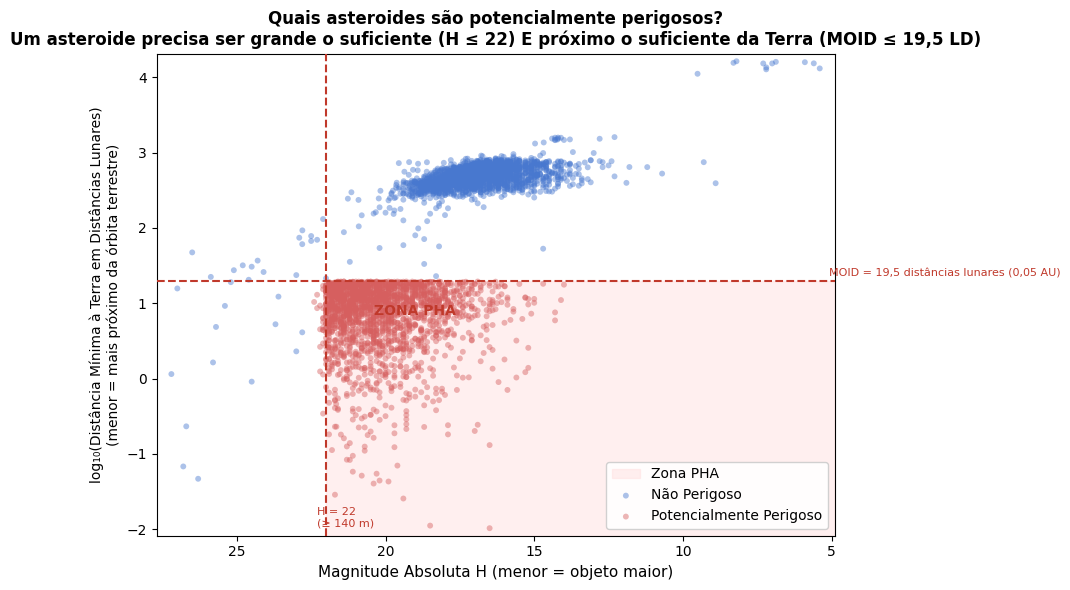

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

tmp = df_sample[['pha', 'H', 'moid_ld']].dropna()
tmp = tmp[tmp['moid_ld'] > 0].copy()
tmp['log_moid'] = np.log10(tmp['moid_ld'])
ymin = tmp['log_moid'].min() - 0.1
ymax = tmp['log_moid'].max() + 0.1
xmin = tmp['H'].min() - 0.5
xmax = tmp['H'].max() + 0.5

ax.fill_betweenx([ymin, np.log10(19.5)], xmin, 22,
                 color='#ffe0e0', alpha=0.5, zorder=0, label='Zona PHA')

palette = {'N': '#4878CF', 'Y': '#D65F5F'}
for label, grp in tmp.groupby('pha'):
    ax.scatter(grp['H'], grp['log_moid'],
               c=palette[label], alpha=0.45, s=18, edgecolors='none',
               label='Potencialmente Perigoso' if label == 'Y' else 'Não Perigoso')

ax.axhline(np.log10(19.5), color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)
ax.axvline(22, color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)

ax.text(22.3, ymin + 0.1, 'H = 22\n(≥ 140 m)', color='#c0392b', fontsize=8, va='bottom')
ax.text(xmin + 0.2, np.log10(19.5) + 0.07,
        'MOID = 19,5 distâncias lunares (0,05 AU)', color='#c0392b', fontsize=8)
ax.text(19, np.log10(19.5) - 0.45, 'ZONA PHA',
        color='#c0392b', fontsize=10, fontweight='bold', ha='center')

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Magnitude Absoluta H (menor = objeto maior)', fontsize=11)
ax.set_ylabel('log₁₀(Distância Mínima à Terra em Distâncias Lunares)\n(menor = mais próximo da órbita terrestre)', fontsize=10)
ax.set_title(
    'Quais asteroides são potencialmente perigosos?\n'
    'Um asteroide precisa ser grande o suficiente (H ≤ 22) E próximo o suficiente da Terra (MOID ≤ 19,5 LD)',
    fontsize=12, fontweight='bold'
)
ax.invert_xaxis()
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

**Como ler este gráfico:** Cada ponto é um asteroide. Quanto mais à esquerda, maior o objeto. Quanto mais abaixo, mais próxima a órbita passa da Terra. A zona rosa marca onde os dois critérios formais de PHA são atendidos simultaneamente.

**Resultado:** Nem o tamanho isolado nem a proximidade isolada definem o perigo — ambos precisam ocorrer juntos.

---

### **2. Formatos das Órbitas por Classe de PHA**

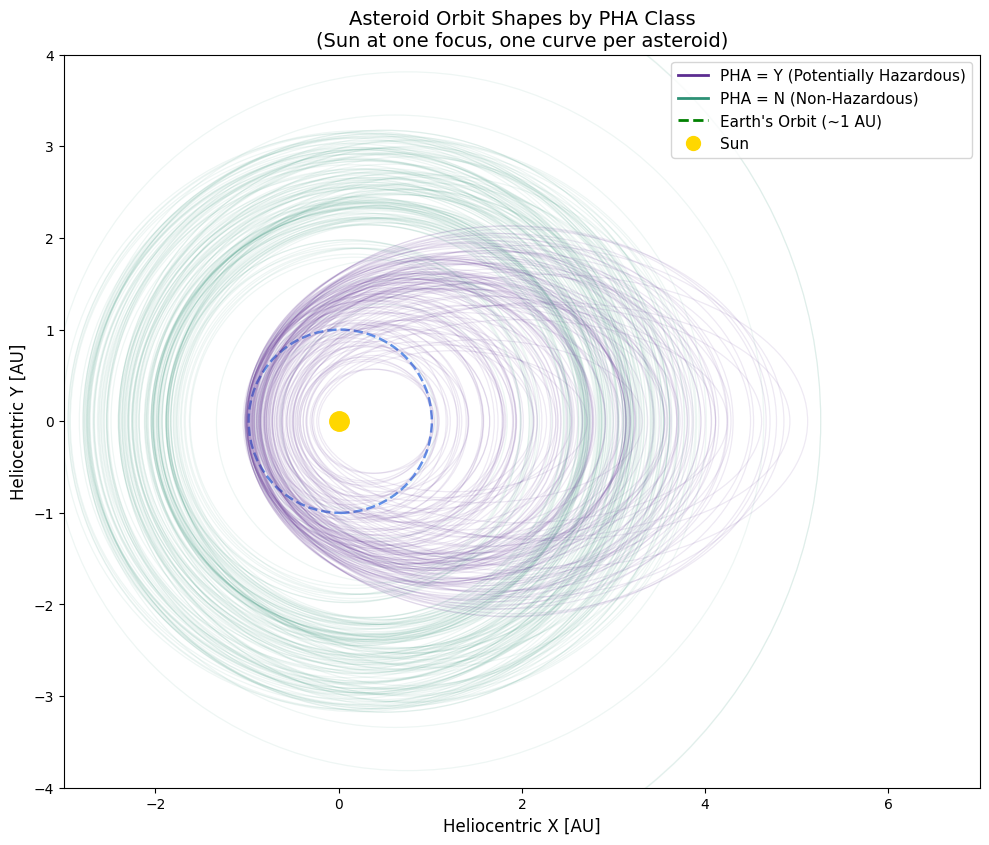

In [ ]:
colors = PHA_COLORS
alphas = {'N': 0.08, 'Y': 0.10}

fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(0, 0, 'o', color='gold', markersize=14, zorder=5)

earth_e = 0.017
earth = MplEllipse(
    xy=(earth_e, 0),
    width=2,
    height=2 * np.sqrt(1 - earth_e**2),
    edgecolor='#6495ED',
    facecolor='none',
    linestyle='--',
    linewidth=1.8
)
ax.add_patch(earth)

for label in ['N', 'Y']:
    sub = ds[ds['pha'] == label].dropna(subset=['a', 'e'])  # <- volta para ds
    sub = sub[(sub['a'] < 6) & (sub['e'] >= 0) & (sub['e'] < 1)]
    sub = sub.sample(n=min(150, len(sub)), random_state=42)

    for _, row in sub.iterrows():
        a_val = row['a']
        e_val = row['e']
        b_val = a_val * np.sqrt(1 - e_val**2)
        c_val = a_val * e_val

        orbit = MplEllipse(
            xy=(c_val, 0),
            width=2 * a_val,
            height=2 * b_val,
            edgecolor=colors[label],
            facecolor='none',
            linewidth=0.9,
            alpha=alphas[label]
        )
        ax.add_patch(orbit)

ax.set_xlim(-3, 7)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('Asteroid Orbit Shapes by PHA Class\n(Sun at one focus, one curve per asteroid)', fontsize=14)
ax.set_xlabel('Heliocentric X [AU]', fontsize=12)
ax.set_ylabel('Heliocentric Y [AU]', fontsize=12)

legend_handles = [
    Line2D([0], [0], color=PHA_COLORS['Y'], lw=2, label='PHA = Y (Potentially Hazardous)'),
    Line2D([0], [0], color=PHA_COLORS['N'], lw=2, label='PHA = N (Non-Hazardous)'),
    Line2D([0], [0], color='green', lw=2, ls='--', label="Earth's Orbit (~1 AU)"),
    Line2D([0], [0], marker='o', color='gold', lw=0, ms=10, label='Sun')
]

ax.legend(handles=legend_handles, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

Após a limpeza:

- 43.386 instâncias (2.066 PHAs e 41.320 não-PHAs);
- 38 atributos;
- **Problema:** classificação binária — `pha = Y` ou `pha = N`
- **Desbalanceamento:** mesmo após a redução, apenas ~4,8% dos asteroides são PHAs — qualquer modelo que preveja sempre "não perigoso" acertaria ~95% das vezes, tornando a acurácia uma métrica inadequada

**Como ler este gráfico:** O ponto dourado é o Sol. A elipse verde é a órbita da Terra. Cada curva colorida é a órbita de um asteroide — 150 por classe amostradas aleatoriamente. Curvas laranja = PHAs; curvas azuis = não-PHAs.

**Resultado:** PHAs têm órbitas visivelmente mais alongadas que cruzam a órbita terrestre. Não-PHAs ficam mais afastados em elipses mais circulares.

---

#### Gráfico Final 3 — Zona de Cruzamento Orbital: Semi-eixo vs Excentricidade

### Final Plot 3 — Orbit Shape vs Size with Earth-Crossing Risk Zone

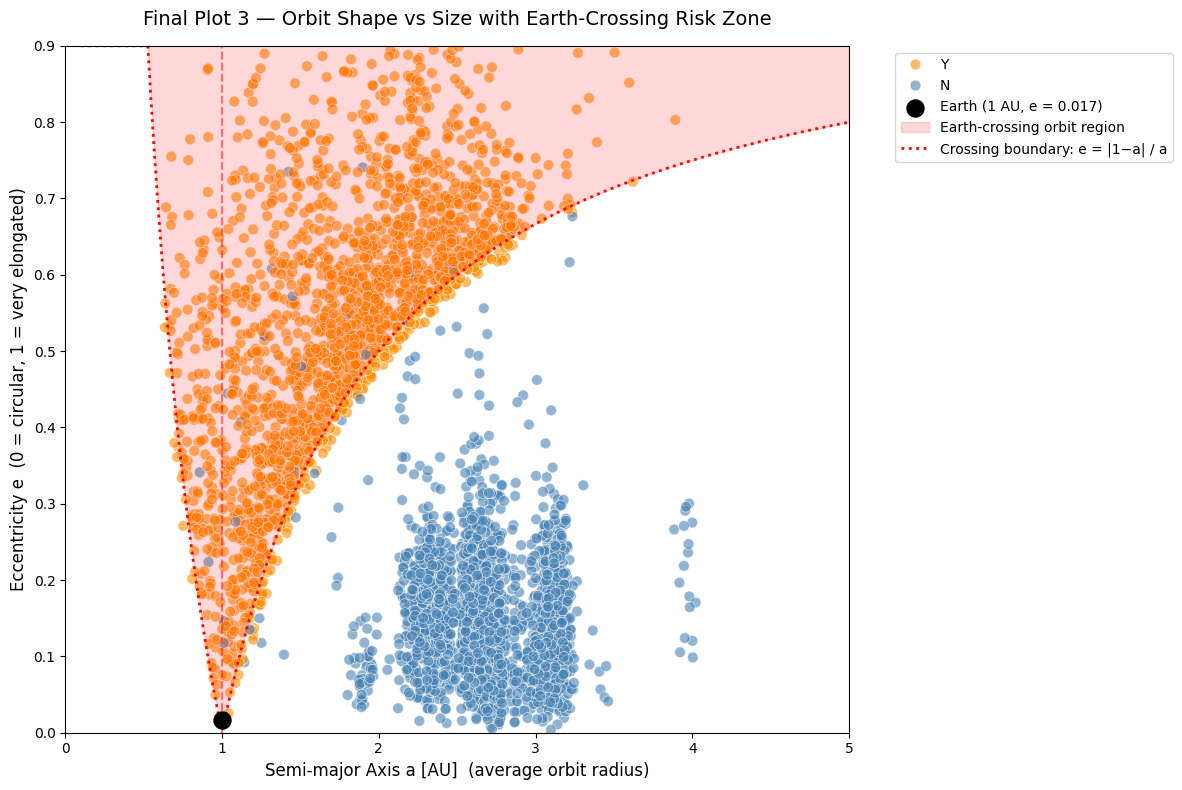

In [ ]:
tmp_final = df_sample[['a', 'e', 'pha']].dropna()
tmp_final = tmp_final[(tmp_final['a'] < 5) & (tmp_final['e'] < 0.9)]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=tmp_final, x='a', y='e', hue='pha',
                palette={'Y': 'darkorange', 'N': 'steelblue'},
                s=60, alpha=0.6)

plt.scatter(1, 0.017, color='black', s=150, zorder=5, edgecolors='black',
            linewidth=1, label='Earth (1 AU, e = 0.017)')

a_range = np.linspace(0.1, 5, 1000)
e_cross = np.abs(1 - a_range) / a_range
e_cross = np.clip(e_cross, 0, 0.9)
plt.fill_between(a_range, e_cross, 0.9, alpha=0.15, color='red',
                 label='Earth-crossing orbit region')
plt.plot(a_range, e_cross, 'r:', linewidth=2,
         label='Crossing boundary: e = |1−a| / a')
plt.axvline(x=1, color='red', ls='--', alpha=0.5)

plt.title('Final Plot 3 — Orbit Shape vs Size with Earth-Crossing Risk Zone',
          fontsize=14, pad=15)
plt.xlabel('Semi-major Axis a [AU]  (average orbit radius)', fontsize=12)
plt.ylabel('Eccentricity e  (0 = circular, 1 = very elongated)', fontsize=12)
plt.xlim(0, 5)
plt.ylim(0, 0.9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()



Enhanced version of Multivariate 3 (a vs e scatter), designed for a lay audience. The key improvement is the **red-shaded risk zone** that marks every orbit physically capable of crossing Earth's distance from the Sun. An asteroid's orbit crosses Earth's if its closest point to the Sun (perihelion = a(1−e)) is less than 1 AU while its farthest point (aphelion = a(1+e)) is greater than 1 AU. Simplifying: **e > |1 − a| / a**.

**How to read this plot:** Each dot is one asteroid. The x-axis is the average orbit radius in AU (1 AU = Earth–Sun distance). The y-axis is eccentricity (0 = circular, 1 = very elongated). The red area marks orbits that cross Earth's distance. The black dot marks Earth itself.

**Como ler este gráfico:** Cada ponto é um asteroide. O eixo horizontal é o raio médio da órbita (1 AU = distância Terra-Sol). O eixo vertical é o alongamento da órbita. A zona vermelha marca as órbitas que fisicamente cruzam a distância da Terra. O ponto preto é a Terra.

**Resultado:** Quase todos os PHAs estão dentro da zona vermelha; os não-PHAs concentram-se fora dela com órbitas circulares e distantes. A fronteira de cruzamento separa as duas populações de forma clara — **a geometria orbital por si só identifica os candidatos a PHA**.

---

**Description:** Each dot is an asteroid. X-axis = average orbit radius (AU). Y-axis = eccentricity. The red zone marks orbits that physically cross Earth’s distance (e > |1−a| / a). Black dot = Earth.

**Key finding:** Nearly all PHAs sit inside the red risk zone; most non-PHAs sit below with circular, distant orbits. The boundary curve cleanly separates the two populations, confirming that **orbital geometry alone** identifies potentially hazardous asteroids.
---

Descrição

Cada curva representa a órbita de um asteroide ao redor do Sol (ponto dourado). As curvas em laranja correspondem a asteroides potencialmente perigosos (`PHA = Y`), enquanto as curvas em azul representam asteroides não perigosos (`PHA = N`). A elipse verde tracejada indica a órbita da Terra. Para melhorar a legibilidade da visualização, foi utilizada uma amostra aleatória de 150 órbitas de cada classe.

Principal Resultado

Os asteroides potencialmente perigosos apresentam, em geral, órbitas mais alongadas (maior excentricidade) e que frequentemente se aproximam ou cruzam a órbita terrestre. Em contraste, os asteroides não perigosos tendem a permanecer mais distantes da região orbital da Terra, concentrando-se principalmente no cinturão principal de asteroides. Essa visualização evidencia de forma intuitiva por que a excentricidade orbital e o semieixo maior são características fundamentais para a identificação de objetos potencialmente perigosos.

---

## Síntese e Reflexão Crítica (*Digest*)

```
Este projeto analisou o dataset de asteroides da NASA com o objetivo de compreender quais características físicas e orbitais distinguem asteroides potencialmente perigosos (PHAs) dos demais, como base para a construção de um modelo de classificação supervisionada.

PRINCIPAIS RESULTADOS

A geometria orbital define a periculosidade. As análises multivariadas confirmaram que as variáveis mais discriminantes são a excentricidade (e), o semi-eixo maior (a) e a distância mínima orbital à Terra (moid_ld). A visualização da fronteira de cruzamento orbital (e > |1 − a| / a) demonstrou que quase todos os PHAs ocupam a região de órbitas que cruzam a distância terrestre.

A descoberta mais importante — e não-óbvia — foi que características físicas de superfície (diâmetro e albedo) não distinguem PHAs de não-PHAs. A análise de dispersão diâmetro × albedo mostrou sobreposição completa entre as classes. O critério de periculosidade é definido pela órbita, não pela composição ou tamanho da superfície.

DECISÕES DE ANÁLISE

Verificamos empiricamente que todos os 2.066 PHAs possuem neo=Y — não existe nenhum PHA com neo=N nos dados. Isso fundamentou o uso de neo como variável relevante para análise sem risco de descartar nenhum objeto da classe positiva.

Para comparações visuais entre classes, utilizamos df_sample — uma amostra igualitária criada na limpeza de dados, com todos os PHAs e o mesmo número de não-PHAs sorteados aleatoriamente. Isso garante comparações visuais equilibradas sem distorção por desbalanceamento, sendo usada apenas para visualização.

O DESAFIO DA MODELAGEM

O desbalanceamento extremo de classes (~0,22% PHAs) exigirá técnicas especiais na etapa de Machine Learning: balanceamento com SMOTE ou Near Miss, e métricas adequadas como F1-score, precisão e recall — acurácia isolada é enganosa para problemas tão desbalanceados.

O QUE FARIA DIFERENTE

A análise de correlação de Spearman deveria ter sido realizada antes das visualizações multivariadas individuais, guiando a seleção de variáveis desde o início e evitando análises redundantes entre a, ad, per_y e n. Também subestimamos o impacto da ausência de dados em diameter e albedo — H acabou sendo a única variável física viável como feature.
```

## Machine Learning *(pós-checkpoint)*

Serão desenvolvidos ao menos 3 modelos de classificação para identificar PHAs.

Aspectos a cobrir:
- Seleção de features baseada nas análises exploratórias
- Protocolo de validação adequado para dados desbalanceados
- Técnicas de balanceamento: SMOTE e/ou Near Miss
- Métricas: F1-score, precisão, recall, AUC-ROC
- Comparação com e sem a variável `moid_ld`

In [ ]:
# células de Machine Learning serão adicionadas aqui

## Etapas para Submissão Final

1. Executar todas as células e verificar que os outputs estão visíveis;
2. Salvar como Jupyter Notebook (`.ipynb`);
3. Exportar cópia em PDF (`.pdf`);
4. Compactar notebook, PDF e dataset em `EquipeXX.zip`;
5. Fazer upload no Canvas.